In [ ]:
from google.colab import  drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets seqeval torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=829189171d3f31f8099d7d30407da3ded6f9976b85644cb6d1bc4ca56a77150f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
#from transformers import BertTokenizer
import unicodedata
import os
import numpy as np
import json
from sklearn.model_selection import train_test_split

# Load dataset

In [ ]:
#dataset_path = '/content/drive/MyDrive/datasets/joint_extraction/dnrti_bert.json'
dataset_path ='/content/drive/MyDrive/datasets/joint_extraction/dnrti_for_je.json'

def write_to_file(dataset, filename):
    with open(filename, 'w') as file:
        json.dump(dataset, file, indent=4)
# Load the dataset
with open(dataset_path, 'r') as f:
    data = json.load(f)

# Split the dataset into train, test, and validation sets
train_data, temp_data = train_test_split(data, test_size=0.25, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")



Training data size: 4934
Validation data size: 822
Test data size: 823


In [ ]:
dataset_path = 'train.json'
write_to_file(train_data, dataset_path)
dataset_path = 'dev.json'
write_to_file(val_data, dataset_path)
dataset_path = 'test.json'
write_to_file(test_data, dataset_path)

In [ ]:
train_data[0]

{'text': 'A China-based cyber threat group , which FireEye tracks as an uncategorized advanced persistent threat , APT group and other researchers refer to as admin@338 , may have conducted the activity .',
 'entities': [[1, 2, 'China-based', 'Area'],
  [2, 4, 'cyber threat', 'HackOrg'],
  [7, 8, 'FireEye', 'SecTeam'],
  [16, 17, 'APT', 'HackOrg'],
  [24, 25, 'admin@338', 'HackOrg'],
  [30, 31, 'activity', 'OffAct']],
 'relations': [['targetedBy', 1, 0],
  ['noRelation', 2, 0],
  ['targetedBy', 3, 0],
  ['targetedBy', 4, 0],
  ['targetedBy', 5, 0],
  ['discoveredBy', 2, 1],
  ['associatedWith', 3, 1],
  ['associatedWith', 4, 1],
  ['uses', 5, 1],
  ['discovers', 3, 2],
  ['discovers', 4, 2],
  ['monitors', 5, 2],
  ['associatedWith', 4, 3],
  ['uses', 5, 3],
  ['uses', 5, 4]],
 'ent_labels': ['O',
  'B-Area',
  'B-HackOrg',
  'I-HackOrg',
  'O',
  'O',
  'O',
  'B-SecTeam',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-HackOrg',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',


# tokenization.py

In [ ]:
# with open("tokenization.py", "w") as f:
#     f.write('''

from transformers import AutoTokenizer
import unicodedata


def _run_strip_accents(text):
    """Strips accents from a piece of text."""
    text = unicodedata.normalize("NFD", text)
    output = []
    for char in text:
        cat = unicodedata.category(char)
        if cat == "Mn":  # Mn means "Nonspacing Mark"
            continue
        output.append(char)
    return "".join(output)


class BERTTextEncoder(object):
    def __init__(self, model_name: str='bert-base-cased', do_lower_case: bool = True) -> None:
        # Load AutoTokenizer for the pre-trained model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=do_lower_case)

        # Get special token IDs from the tokenizer
        self.bert_pad_id = self.tokenizer.pad_token_id
        self.bert_unk_id = self.tokenizer.unk_token_id
        self.bert_cls_id = self.tokenizer.cls_token_id
        self.bert_sep_id = self.tokenizer.sep_token_id
        self.bert_msk_id = self.tokenizer.mask_token_id

    def standardize_ids(self, ids):
        vocab_size = len(self.tokenizer.vocab)
        for i in range(len(ids)):
            if ids[i] == self.bert_pad_id:  # PAD
                ids[i] = 1 + vocab_size
            elif ids[i] == self.bert_unk_id:  # UNK
                ids[i] = 0
            elif ids[i] == self.bert_cls_id:  # CLS
                ids[i] = 3 + vocab_size
            elif ids[i] == self.bert_sep_id:  # SEP
                ids[i] = 5 + vocab_size
            elif ids[i] == self.bert_msk_id:  # MASK
                ids[i] = 2 + vocab_size
            elif ids[i] > self.bert_msk_id:  # VOCAB
                ids[i] -= self.bert_msk_id
        return ids

    def tokenize(self, text: str):
        """Tokenize input text using AutoTokenizer and return token data."""
        # Tokenize using AutoTokenizer with word-level and subword information
        encoding = self.tokenizer(text, return_offsets_mapping=True, is_split_into_words=False)

        tokens = encoding.tokens()  # Actual tokens
        token_ids = encoding['input_ids']  # Token IDs
        offset_mapping = encoding['offset_mapping']  # Character-level offsets for each token
        word_ids = encoding.word_ids()  # Word-level mapping is extracted here

        return tokens, token_ids, offset_mapping, word_ids

    def convert_tokens_to_ids(self, tokens):
        return self.tokenizer.convert_tokens_to_ids(tokens)

    def convert_ids_to_tokens(self, token_ids):
        """Converts token IDs back to tokens."""
        return self.tokenizer.convert_ids_to_tokens(token_ids)



  #''')

In [ ]:
# from transformers import AutoTokenizer

# # Initialize the tokenizer
# tokenizer = AutoTokenizer.from_pretrained('bert-base-cased')

# # # Save the tokenizer to a specific directory
# tokenizer.save_pretrained('./pretrain_weights/bert-base-cased/')

In [ ]:
# with open("config.py", "w") as f:
#     f.write('''

import os
#from tokenization import BERTTextEncoder

# Define the path to the pre-trained BERT model (bert-base-uncased)
#bert_parameter_location = '/content/pretrain_weights/bert-base-cased'
# Load the BERT tokenizer
bert_encoder = BERTTextEncoder(model_name='bert-base-cased')

projectName = 'relation_extraction_bert_attention_model_joint_NER_RC_task'


neid2type = {
    0: 'null',      # null class
    1: 'O',
    2: 'B-Area',
    3: 'I-Area',
    4: 'B-Exp',
    5: 'I-Exp',
    6: 'B-Features',
    7: 'I-Features',
    8: 'B-HackOrg',
    9: 'I-HackOrg',
    10: 'B-OffAct',
    11: 'I-OffAct',
    12: 'B-Org',
    13: 'I-Org',
    14: 'B-Purp',
    15: 'I-Purp',
    16: 'B-SamFile',
    17: 'I-SamFile',
    18: 'B-SecTeam',
    19: 'I-SecTeam',
    20: 'B-Time',
    21: 'I-Time',
    22: 'B-Tool',
    23: 'I-Tool',
    24: 'B-Way',
    25: 'I-Way'
}

# RE relation types (provided by you)
# reid2type = {
#     0: 'null',          # null class for no relation
#     1: 'noRelation',
#     2: 'targets',
#     3: 'uses',
#     4: 'locatedAt',
#     5: 'hasAttackTime',
#     6: 'hasCharacteristics',
#     7: 'associatedWith',
#     8: 'discovers',
#     9: 'monitors',
#     10: 'motivates',
#     11: 'analyses'
# }
reid2type = {
    0: 'null',          # null class for no relation
    1: 'noRelation',
    2: 'targets',
    3: 'uses',
    4: 'locatedAt',
    5: 'hasAttackTime',
    6: 'hasCharacteristics',
    7: 'associatedWith',
    8: 'discovers',
    9: 'monitors',
    10: 'motivates',
    11: 'analyses',
    12: 'targetedBy',
    13: 'usedBy',
    14: 'discoveredBy',
    15: 'monitoredBy',
    16: 'motivatedBy'
}

#unique_relations = ['<PAD>', 'targets', 'uses', 'targetedBy', 'locatedAt', 'hasAttackTime', 'usedBy', 'hasCharacteristics', 'associatedWith', 'discovers', 'monitors', 'motivatedBy', 'discoveredBy', 'monitoredBy', 'motivates', 'analyses']

# Create reverse mappings for entity and relation types
netype2id = {v: k for k, v in neid2type.items()}
retype2id = {v: k for k, v in reid2type.items()}

#''')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
netype2id, neid2type

({'null': 0,
  'O': 1,
  'B-Area': 2,
  'I-Area': 3,
  'B-Exp': 4,
  'I-Exp': 5,
  'B-Features': 6,
  'I-Features': 7,
  'B-HackOrg': 8,
  'I-HackOrg': 9,
  'B-OffAct': 10,
  'I-OffAct': 11,
  'B-Org': 12,
  'I-Org': 13,
  'B-Purp': 14,
  'I-Purp': 15,
  'B-SamFile': 16,
  'I-SamFile': 17,
  'B-SecTeam': 18,
  'I-SecTeam': 19,
  'B-Time': 20,
  'I-Time': 21,
  'B-Tool': 22,
  'I-Tool': 23,
  'B-Way': 24,
  'I-Way': 25},
 {0: 'null',
  1: 'O',
  2: 'B-Area',
  3: 'I-Area',
  4: 'B-Exp',
  5: 'I-Exp',
  6: 'B-Features',
  7: 'I-Features',
  8: 'B-HackOrg',
  9: 'I-HackOrg',
  10: 'B-OffAct',
  11: 'I-OffAct',
  12: 'B-Org',
  13: 'I-Org',
  14: 'B-Purp',
  15: 'I-Purp',
  16: 'B-SamFile',
  17: 'I-SamFile',
  18: 'B-SecTeam',
  19: 'I-SecTeam',
  20: 'B-Time',
  21: 'I-Time',
  22: 'B-Tool',
  23: 'I-Tool',
  24: 'B-Way',
  25: 'I-Way'})

In [ ]:
def tokenize_and_align_labels(bert_encoder, text, entity_labels, label2id):
    # Preprocess text to handle abbreviations like "U.S."
    preprocessed_text = preprocess_text(text)

    # Tokenize the preprocessed text using BERTTextEncoder's tokenize function
    tokens, token_ids, offset_mapping, word_ids = bert_encoder.tokenize(preprocessed_text)

    aligned_labels = []
    prev_word_id = None

    # Align labels to tokens using the word_ids
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            aligned_labels.append(label2id["O"])  # Use "O" for special tokens like [CLS], [SEP]
        elif word_id == prev_word_id:
            aligned_labels.append(aligned_labels[-1])  # If same word split into subwords
        else:
            # Get the label corresponding to the original word index
            label = entity_labels[word_id] if word_id < len(entity_labels) else "O"
            aligned_labels.append(label2id.get(label, label2id["O"]))
        prev_word_id = word_id

    return tokens, aligned_labels, token_ids


In [ ]:
import re
def preprocess_text(text):
    # Match abbreviations like "U.S.", "A.T.P.", etc., and ensure the final period is optional but removed
    abbreviation_pattern = re.compile(r'\b([A-Z])\.([A-Z])(?:\.([A-Z]))?\b\.')

    # Replace abbreviations by removing the periods
    modified_text = abbreviation_pattern.sub(lambda m: ''.join(m.groups('')), text)

    return modified_text

# Example usage
text = "In this same time frame, APT10 also targeted a U.S. law firm and an international apparel company."
modified_text = preprocess_text(text)
print(modified_text)


In this same time frame, APT10 also targeted a US law firm and an international apparel company.


In [ ]:
#text = "In this same time frame , APT10 also targeted a U.S. law firm and an international apparel company , likely to gather information for commercial advantage."
text = "Since August 2018 , the Machete components have been delivered with an extra layer of obfuscation "
# ent_labels = [
#     "O", "O", "O", "O", "O", "O", "B-HackOrg", "O", "O", "O",
#     "B-Org", "I-Org", "I-Org", "O", "O", "O", "B-Org", "I-Org",
#     "O", "O", "O", "B-Purp", "I-Purp", "O", "O", "O", "O"
# ]
ent_labels =  ['O', 'B-Time', 'I-Time', 'O', 'O', 'B-HackOrg', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
#netype2id = {'null': 0, 'O': 1, 'B-HackOrg': 8, 'I-HackOrg': 9, 'B-Org': 12, 'I-Org': 13, 'B-Purp': 14, 'I-Purp': 15}
netype2id = {'null': 0,
  'O': 1,
  'B-Area': 2,
  'I-Area': 3,
  'B-Exp': 4,
  'I-Exp': 5,
  'B-Features': 6,
  'I-Features': 7,
  'B-HackOrg': 8,
  'I-HackOrg': 9,
  'B-OffAct': 10,
  'I-OffAct': 11,
  'B-Org': 12,
  'I-Org': 13,
  'B-Purp': 14,
  'I-Purp': 15,
  'B-SamFile': 16,
  'I-SamFile': 17,
  'B-SecTeam': 18,
  'I-SecTeam': 19,
  'B-Time': 20,
  'I-Time': 21,
  'B-Tool': 22,
  'I-Tool': 23,
  'B-Way': 24,
  'I-Way': 25}

# Initialize the BERTTextEncoder
bert_encoder = BERTTextEncoder(model_name='bert-base-cased')

# Tokenize and align the labels
tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

print(f"Aligned Labels: {aligned_labels}")
#print(f"Tokenized Inputs: {tokenized_inputs['input_ids']}")
print(f"Tokens: {tokens}")
tokens2ids = bert_encoder.convert_tokens_to_ids(tokens)
print(f"Tokens2Ids: {tokens2ids}")
ids2tokens = bert_encoder.convert_ids_to_tokens(tokens2ids)
print(f"Ids2Tokens: {ids2tokens}")
labels = [neid2type[label] for label in aligned_labels]
# Print the token-label pairs
for token, label in zip(tokens, labels):
    print(f'{token:15} {label}')


Aligned Labels: [1, 1, 20, 20, 20, 21, 1, 1, 8, 8, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tokens: ['[CLS]', 'since', 'au', '##gus', '##t', '2018', ',', 'the', 'mac', '##he', '##te', 'components', 'have', 'been', 'delivered', 'with', 'an', 'extra', 'layer', 'of', 'o', '##b', '##fu', '##sca', '##tion', '[SEP]']
Tokens2Ids: [101, 1290, 12686, 12909, 1204, 1857, 117, 1103, 23639, 4638, 1566, 5644, 1138, 1151, 4653, 1114, 1126, 3908, 6440, 1104, 184, 1830, 14703, 26996, 2116, 102]
Ids2Tokens: ['[CLS]', 'since', 'au', '##gus', '##t', '2018', ',', 'the', 'mac', '##he', '##te', 'components', 'have', 'been', 'delivered', 'with', 'an', 'extra', 'layer', 'of', 'o', '##b', '##fu', '##sca', '##tion', '[SEP]']
[CLS]           O
since           O
au              B-Time
##gus           B-Time
##t             B-Time
2018            I-Time
,               O
the             O
mac             B-HackOrg
##he            B-HackOrg
##te            B-HackOrg
components      O
have            O
been   

In [ ]:
def generate_mapped_entities(tokens, labels):
    maped_entities = []
    token_label_pairs = list(zip(tokens, labels))
    idx = 0

    while idx < len(token_label_pairs):
        token, label = token_label_pairs[idx]

        if label.startswith('B-'):  # Beginning of an entity
            start_idx = idx
            entity_type = label[2:]  # Get the entity type (e.g., 'HackOrg')

            # Move to the next token and continue until we no longer find subwords or I-* labels
            while (idx + 1 < len(token_label_pairs) and
                   (token_label_pairs[idx + 1][1].startswith('I-') or token_label_pairs[idx + 1][0].startswith('##'))):
                idx += 1

            # End of the entity (the current idx is the last token of the entity)
            end_idx = idx + 1
            maped_entities.append((start_idx, end_idx, entity_type))

        idx += 1

    return maped_entities


tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

labels = [neid2type[label] for label in aligned_labels]
maped_entities = generate_mapped_entities(tokens, labels)

# Print the mapped entities with start and end indexes
for entity in maped_entities:
    print(f"Entity: {entity[2]}, Start: {entity[0]}, End: {entity[1]}")


Entity: Time, Start: 2, End: 6
Entity: HackOrg, Start: 8, End: 11


In [ ]:
def generate_pos_ids(batch_size: int, max_len: int) -> np.array:
    return np.repeat(np.arange(max_len, dtype=np.int32).reshape(1, -1), batch_size, 0)

In [ ]:
data_path = '/content/'
max_len = 150

In [ ]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.utils import to_categorical

def re_data_to_input_output(model_data, bert_encoder, max_len):
    input_ids, input_masks, input_entity_masks = [], [], []
    output_re_ids, output_ne_ids = [], []
    entity_type_ids = []  # New list to hold entity type IDs

    for item in tqdm(model_data):
        # Extract the full sentence from the 'text' key
        text = item['text']
        entities = item['entities']
        relations = item['relations']
        ent_labels = item['ent_labels']

        # print(f"\nProcessing text: {text}")
        # print(f"Entities: {entities}")
        # print(f"Relations: {relations}")
        # print(f"Entity Labels (BIO): {ent_labels}")

        # Tokenize and align labels
        tokens, aligned_labels, tokenized_inputs = tokenize_and_align_labels(bert_encoder, text, ent_labels, netype2id)

        # print(f"Tokenized sentence: {tokens}")
        # print(f"Aligned labels: {aligned_labels}")

        # Convert aligned labels to their corresponding indices (leave them as class indices, no need for one-hot encoding)
        labels = [neid2type[label] for label in aligned_labels]
       # print(f"NER Labels for each token: {labels}")

        mapped_entities = generate_mapped_entities(tokens, labels)
        #print(f"Mapped Entities: {mapped_entities}")

        # Create the relation mapping
        #relation_map = {(start_entity_idx, end_entity_idx): relation_type for relation_type, start_entity_idx, end_entity_idx in relations}
        relation_map = {(start_entity_idx, end_entity_idx): relation_type for relation_type, end_entity_idx, start_entity_idx in relations}
       # print(f"Relation Map: {relation_map}")

        # Initialize BIO tags for each token
        netype_list = ['O'] * len(tokens)
        input_id = tokenized_inputs

        # Assign BIO tags based on the mapped entities
        for start_pos, end_pos, entity_type in mapped_entities:
            if end_pos - start_pos == 1:
                netype_list[start_pos] = "B-" + entity_type  # Single-token entities
            else:
                netype_list[start_pos] = "B-" + entity_type
                for tmp_pos in range(start_pos + 1, end_pos - 1):
                    netype_list[tmp_pos] = "I-" + entity_type
                netype_list[end_pos - 1] = "I-" + entity_type  # Mark the end of the entity with 'I'

        #print(f"BIO Tags for tokens: {netype_list}")

        # Prepare relation extraction inputs
        relation_entity_type_ids = []
        for start_entity_idx in range(len(entities)):
            for end_entity_idx in range(start_entity_idx + 1, len(entities)):
                remask = [0] * len(tokens)  # Reset remask for each entity pair

                # Map the entities to their token positions
                if start_entity_idx < len(mapped_entities) and mapped_entities[start_entity_idx]:
                    for tmp_pos in range(mapped_entities[start_entity_idx][0], mapped_entities[start_entity_idx][1]):
                        remask[tmp_pos] = 1

                if end_entity_idx < len(mapped_entities) and mapped_entities[end_entity_idx]:
                    for tmp_pos in range(mapped_entities[end_entity_idx][0], mapped_entities[end_entity_idx][1]):
                        remask[tmp_pos] = 1

                # Get relation type, default to 'noRelation'
                retype = relation_map.get((start_entity_idx, end_entity_idx), 'noRelation')
                input_tokens = tokens
                start_entity_type = entities[start_entity_idx][3]
                end_entity_type = entities[end_entity_idx][3]

                start_entity_type ='B-'+ start_entity_type
                end_entity_type ='B-'+ end_entity_type
                #print(f"Start Entity Type: {start_entity_type}, End Entity Type: {end_entity_type}")
                start_entity_type_id = netype2id[start_entity_type]
                end_entity_type_id = netype2id[end_entity_type]

                #print(f"Start Entity Type: {start_entity_type}, End Entity Type: {end_entity_type}")

                # Convert tokens to IDs and create masks
                #input_id = bert_encoder.standardize_ids(bert_encoder.convert_tokens_to_ids(input_tokens))
                input_mask = [1] * len(input_tokens)
                input_entity_mask = [0] + remask + [0]

                # Convert relation type to ID
                output_re_id = retype2id[retype]

                # Prepare output for NER and RE (Note: We no longer one-hot encode NER labels)
                output_netype_list = ['null'] + netype_list + ['null']
                output_ne_id = [netype2id[item] for item in output_netype_list]  # These remain class indices

                # Padding for input and output sequences
                input_id += [0] * (max_len - len(input_id))
                input_mask += [0] * (max_len - len(input_mask))
                input_entity_mask += [0] * (max_len - len(input_entity_mask))
                output_ne_id += [0] * (max_len - len(output_ne_id))

                input_ids.append(input_id)
                input_masks.append(input_mask)
                input_entity_masks.append(input_entity_mask)
                output_re_ids.append(output_re_id)
                output_ne_ids.append(output_ne_id)  # No one-hot encoding here
                relation_entity_type_ids.append([start_entity_type_id, end_entity_type_id])
        entity_type_ids.extend(relation_entity_type_ids)
    #print(f"Relation Entity Type IDs: {relation_entity_type_ids}")
    # for i, input_id in enumerate(input_ids):
    #   print(f"Sample {i} length: {len(input_id)}")
    # if len(input_id) != max_len:
    #     print(f"Sample {i} has incorrect length: {len(input_id)}")

    # Convert lists to numpy arrays

    input_ids = np.array(input_ids, dtype=np.int32)
    input_masks = np.array(input_masks, dtype=np.int32)
    input_entity_masks = np.array(input_entity_masks, dtype=np.int32)
    entity_type_ids = np.array(entity_type_ids, dtype=np.int32)  # Ensure proper shape for entity type IDs
    output_re_ids = np.array(output_re_ids, dtype=np.int32)
    output_ne_ids = np.array(output_ne_ids, dtype=np.int32)  # Should remain as class indices

    # Generate positional IDs and type IDs
    pos = generate_pos_ids(len(input_ids), max_len)
    input_type_ids = np.zeros((len(input_ids), max_len), dtype=np.int32)

    # Prepare y_train outputs
    y_train = [
        output_ne_ids,
       output_re_ids
    ]


    return [input_ids, input_masks, input_entity_masks, entity_type_ids], y_train


In [ ]:
# Load data
train_data = json.load(open(data_path + "train.json"))
dev_data = json.load(open(data_path + "dev.json"))
test_data = json.load(open(data_path + "test.json"))

print(f"Train Data: {len(train_data)}, Dev Data: {len(dev_data)}, Test Data: {len(test_data)}")

# train_data_subset = train_data[:2]
# test_data_subset = test_data[:2]
# dev_data_subset = dev_data[:2]

# Execute the data preparation function
x_train, y_train = re_data_to_input_output(train_data, bert_encoder, max_len)
#x_train, y_train = re_data_to_input_output(train_data_subset, bert_encoder, max_len)


Train Data: 4934, Dev Data: 822, Test Data: 823


100%|██████████| 4934/4934 [00:04<00:00, 1159.71it/s]


In [ ]:
netype2id

{'null': 0,
 'O': 1,
 'B-Area': 2,
 'I-Area': 3,
 'B-Exp': 4,
 'I-Exp': 5,
 'B-Features': 6,
 'I-Features': 7,
 'B-HackOrg': 8,
 'I-HackOrg': 9,
 'B-OffAct': 10,
 'I-OffAct': 11,
 'B-Org': 12,
 'I-Org': 13,
 'B-Purp': 14,
 'I-Purp': 15,
 'B-SamFile': 16,
 'I-SamFile': 17,
 'B-SecTeam': 18,
 'I-SecTeam': 19,
 'B-Time': 20,
 'I-Time': 21,
 'B-Tool': 22,
 'I-Tool': 23,
 'B-Way': 24,
 'I-Way': 25}

In [ ]:
x_dev, y_dev = re_data_to_input_output(dev_data, bert_encoder, max_len)
x_test, y_test = re_data_to_input_output(test_data, bert_encoder, max_len)

# x_dev, y_dev = re_data_to_input_output(dev_data_subset, bert_encoder, max_len)
# x_test, y_test = re_data_to_input_output(test_data_subset, bert_encoder, max_len)

100%|██████████| 823/823 [00:00<00:00, 3498.51it/s]


In [ ]:
#2 + 'p'

In [ ]:
y_train

[array([[0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        ...,
        [0, 1, 8, ..., 0, 0, 0],
        [0, 1, 8, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0]], dtype=int32),
 array([12,  1, 12, ...,  3,  3, 12], dtype=int32)]

Relation label distribution: {np.int32(1): np.int64(13314), np.int32(2): np.int64(4691), np.int32(3): np.int64(3829), np.int32(4): np.int64(1178), np.int32(5): np.int64(958), np.int32(6): np.int64(942), np.int32(7): np.int64(552), np.int32(8): np.int64(510), np.int32(9): np.int64(941), np.int32(10): np.int64(135), np.int32(11): np.int64(130), np.int32(12): np.int64(946), np.int32(13): np.int64(2006), np.int32(14): np.int64(120), np.int32(15): np.int64(75), np.int32(16): np.int64(839)}


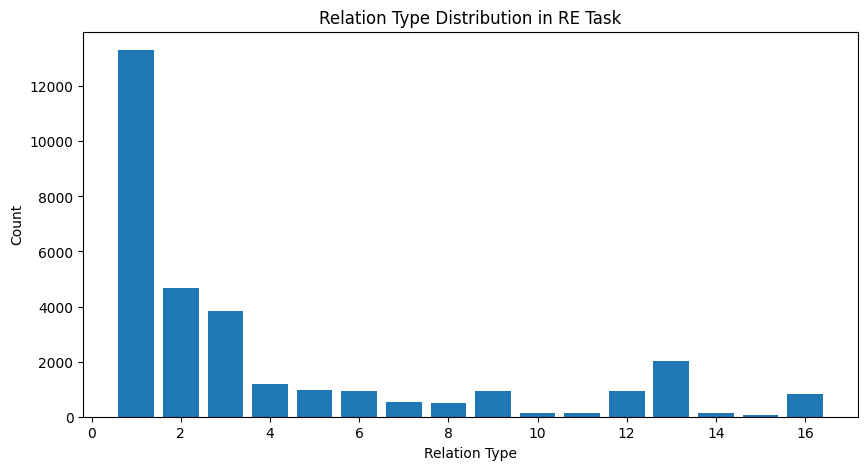

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


In [ ]:
from collections import Counter
import numpy as np

# Define the target oversampling counts
#target_oversample = {2: 2000, 5: 2000, 3: 2000, 4: 2000, 6: 2000, 7: 2000, 8: 2000, 9: 2000, 10: 2500, 11: 2500}
#target_oversample = {1: 18576, 2: 4993, 3: 4114, 4: 2257, 5: 2110, 6: 2087, 7: 2057, 8: 2050, 9: 2212, 10: 2020, 11: 2000}
target_oversample = {1: 18576, 2: 4993, 3: 4114, 4: 2257, 5: 2110, 6: 2087, 7: 2057, 8: 2050, 9: 2212, 10: 2020, 11: 2023, 12: 2018, 13: 3000, 14: 2005, 15: 2000, 16: 2050}

def oversample_classes(x_train, y_train, target_oversample):
    input_ids, attention_mask, entity_mask, entity_type_ids = x_train
    ner_labels, re_labels = y_train

    # Convert everything to lists for easier manipulation
    input_ids = input_ids.tolist()
    attention_mask = attention_mask.tolist()
    entity_mask = entity_mask.tolist()
    entity_type_ids = entity_type_ids.tolist()  # New addition
    ner_labels = ner_labels.tolist()
    re_labels = re_labels.tolist()

    # Create containers for the resampled data
    resampled_input_ids, resampled_attention_mask = input_ids[:], attention_mask[:]
    resampled_entity_mask, resampled_entity_type_ids = entity_mask[:], entity_type_ids[:]
    resampled_ner_labels, resampled_re_labels = ner_labels[:], re_labels[:]

    # Count original class distribution
    class_counter = Counter(re_labels)

    # Oversample based on the defined target counts, but only for classes below the target
    for class_label, target_count in target_oversample.items():
        current_count = class_counter[class_label]

        if current_count < target_count:
            # Get the indices of samples with this class label
            indices = [i for i, label in enumerate(re_labels) if label == class_label]
            additional_samples_needed = target_count - current_count

            # Select samples to oversample, ensuring the required amount is added
            additional_samples = np.random.choice(indices, size=additional_samples_needed, replace=True)

            # Append oversampled data
            resampled_input_ids.extend([input_ids[i] for i in additional_samples])
            resampled_attention_mask.extend([attention_mask[i] for i in additional_samples])
            resampled_entity_mask.extend([entity_mask[i] for i in additional_samples])
            resampled_entity_type_ids.extend([entity_type_ids[i] for i in additional_samples])  # Add entity type IDs
            resampled_ner_labels.extend([ner_labels[i] for i in additional_samples])
            resampled_re_labels.extend([re_labels[i] for i in additional_samples])

    # Convert back to NumPy arrays
    x_train_resampled = [
        np.array(resampled_input_ids, dtype=np.int32),
        np.array(resampled_attention_mask, dtype=np.int32),
        np.array(resampled_entity_mask, dtype=np.int32),
        np.array(resampled_entity_type_ids, dtype=np.int32)  # Include the entity type IDs
    ]
    y_train_resampled = [
        np.array(resampled_ner_labels, dtype=np.int32),
        np.array(resampled_re_labels, dtype=np.int32)
    ]

    return x_train_resampled, y_train_resampled

# Apply the corrected oversampling
x_train_resampled, y_train_resampled = oversample_classes(x_train, y_train, target_oversample)

# Check the new distribution
new_class_distribution = Counter(y_train_resampled[1])
print("Resampled class distribution:", new_class_distribution)



Resampled class distribution: Counter({np.int32(1): 18576, np.int32(2): 4993, np.int32(3): 4114, np.int32(13): 3000, np.int32(4): 2257, np.int32(9): 2212, np.int32(5): 2110, np.int32(6): 2087, np.int32(7): 2057, np.int32(8): 2050, np.int32(16): 2050, np.int32(11): 2023, np.int32(10): 2020, np.int32(12): 2018, np.int32(14): 2005, np.int32(15): 2000})


In [ ]:
import numpy as np
from collections import Counter

# y_train_resampled[1] should be the RE labels part of y_train
re_labels_resampled = np.array(y_train_resampled[1])

# Set the target count for undersampling "noRelation" (Class 1)
no_relation_target_count = 8000  # You can change this to 7000 or another value as needed

# Get the indices for 'noRelation' class (class 1)
no_relation_indices = np.where(re_labels_resampled == 1)[0]

# Randomly sample the required number of "noRelation" samples
undersample_indices = np.random.choice(no_relation_indices, no_relation_target_count, replace=False)

# Get the indices for the rest of the classes (non-"noRelation")
non_no_relation_indices = np.where(re_labels_resampled != 1)[0]

# Combine the undersampled "noRelation" indices with the non-"noRelation" indices
final_indices = np.concatenate([undersample_indices, non_no_relation_indices])

# Use these indices to filter x_train_resampled and y_train_resampled
x_train_final = [x[final_indices] for x in x_train_resampled]  # Filter each element in x_train_resampled
y_train_final = [
    y_train_resampled[0][final_indices],  # Filter NER labels (part of y_train_resampled)
    re_labels_resampled[final_indices]    # Filter RE labels
]

# Verify the new distribution after undersampling
new_class_distribution = Counter(y_train_final[1])  # Check RE label distribution
print(f"New class distribution after undersampling: {new_class_distribution}")


New class distribution after undersampling: Counter({np.int32(1): 8000, np.int32(2): 4993, np.int32(3): 4114, np.int32(13): 3000, np.int32(4): 2257, np.int32(9): 2212, np.int32(5): 2110, np.int32(6): 2087, np.int32(7): 2057, np.int32(8): 2050, np.int32(16): 2050, np.int32(11): 2023, np.int32(10): 2020, np.int32(12): 2018, np.int32(14): 2005, np.int32(15): 2000})


In [ ]:
x_train_final

[array([[  101,   170,  6451, ...,     0,     0,     0],
        [  101,   187, 13356, ...,     0,     0,     0],
        [  101,  1359,  1113, ...,     0,     0,     0],
        ...,
        [  101,   170,  6451, ...,     0,     0,     0],
        [  101,  1610, 21182, ...,     0,     0,     0],
        [  101,  5136,  1104, ...,     0,     0,     0]], dtype=int32),
 array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], dtype=int32),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 array([[12, 12],
        [ 2, 12],
        [ 2,  2],
        ...,
        [ 4, 14],
        [22, 14],
        [24, 14]], dtype=int32)]

Relation label distribution: {np.int32(1): np.int64(8000), np.int32(2): np.int64(4993), np.int32(3): np.int64(4114), np.int32(4): np.int64(2257), np.int32(5): np.int64(2110), np.int32(6): np.int64(2087), np.int32(7): np.int64(2057), np.int32(8): np.int64(2050), np.int32(9): np.int64(2212), np.int32(10): np.int64(2020), np.int32(11): np.int64(2023), np.int32(12): np.int64(2018), np.int32(13): np.int64(3000), np.int32(14): np.int64(2005), np.int32(15): np.int64(2000), np.int32(16): np.int64(2050)}


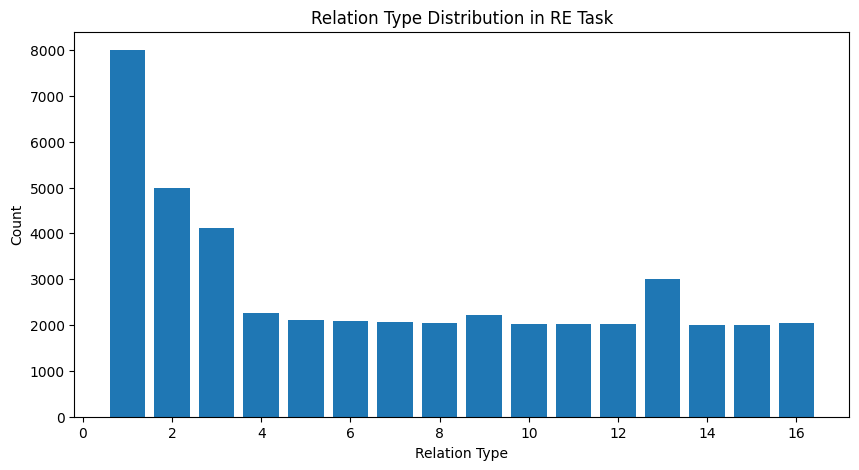

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get RE labels from y_train
re_labels = y_train_final[1]

# Count the occurrences of each relation type
unique, counts = np.unique(re_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

# Display the distribution of relation types
print("Relation label distribution:", label_distribution)

# Plot the distribution of relation types
plt.figure(figsize=(10, 5))
plt.bar(label_distribution.keys(), label_distribution.values())
plt.xlabel('Relation Type')
plt.ylabel('Count')
plt.title('Relation Type Distribution in RE Task')
plt.show()


In [ ]:

# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train[1].shape}")  # Should be (87,)


x_train shapes: [(31166, 150), (31166, 150), (31166, 150), (31166, 2)]
y_train shapes: [(31166, 150), (31166,)]
First element of y_train (NER): (31166, 150)
Second element of y_train (RE): (31166,)


In [ ]:
# Verify the shapes of x_train
print(f"x_train shapes: {[x.shape for x in x_train_final]}")  # Should show shapes of each input array

# Verify the shapes of y_train
print(f"y_train shapes: {[y.shape for y in y_train_final]}")  # Should show shapes of NER and RE outputs

# Ensure the first element in y_train has the correct shape
print(f"First element of y_train (NER): {y_train_final[0].shape}")  # Should be (87, 100, num_classes)
print(f"Second element of y_train (RE): {y_train_final[1].shape}")  # Should be (87,)

x_train shapes: [(44996, 150), (44996, 150), (44996, 150), (44996, 2)]
y_train shapes: [(44996, 150), (44996,)]
First element of y_train (NER): (44996, 150)
Second element of y_train (RE): (44996,)


In [ ]:
x_train[0][1]

array([  101,   170,  5144,  1161,   118,  1359,   172,  1183,  3169,
        4433,  1372,   117,  1134,  1783, 23183,  2390,  1112,  1126,
        8362, 20127, 18791,  2200,  3682, 15970,  4433,   117,   170,
        6451,  1372,  1105,  1168,  6962,  5991,  1106,  1112,  8050,
        7937,   137,  3081,  1604,   117,  1336,  1138,  3303,  1103,
        3246,   119,   102,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

In [ ]:
x_train[3][1]

array([ 2, 18], dtype=int32)

In [ ]:
# Select a sample to display (for example, the first sample)
sample_idx = 1

# Display tokenized input IDs and masks
print(f"Input tokens (input_ids) for sample {sample_idx}:")
print(x_train[0][sample_idx])  # Token IDs
print("\nInput attention mask (input_masks) for sample:")
print(x_train[1][sample_idx])  # Attention Mask
print("\nEntity mask (input_entity_masks) for sample:")
print(x_train[2][sample_idx])  # Entity Mask
print("\nEntity type IDs (entity_type_ids) for sample:")
print(x_train[3][sample_idx])  # Entity type IDs

# Display NER labels
print("\nNER labels (output_ne_ids) for sample:")
print(y_train[0][sample_idx])  # NER labels

# Display RE labels (output_re_ids)
print("\nRE labels (output_re_ids) for sample:")
print(y_train[1][sample_idx])  # RE labels

# You can also display the tokenized input as words by converting the token IDs back to tokens using the tokenizer:
print("\nTokenized sentence:")
tokens = bert_encoder.convert_ids_to_tokens(x_train[0][sample_idx])
print(tokens)


Input tokens (input_ids) for sample 1:
[  101   170  5144  1161   118  1359   172  1183  3169  4433  1372   117
  1134  1783 23183  2390  1112  1126  8362 20127 18791  2200  3682 15970
  4433   117   170  6451  1372  1105  1168  6962  5991  1106  1112  8050
  7937   137  3081  1604   117  1336  1138  3303  1103  3246   119   102
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]

Input attention mask (input_masks) for sample:

In [ ]:
!pip install pytorch-crf

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
import torchcrf
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:


class JointExtractionModel(nn.Module):
    def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
        super(JointExtractionModel, self).__init__()
        self.bert = bert_model

        # Linear projection layer for NER task
        self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

        # Dimentionality reduction
        self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size * 3, bert_model.config.hidden_size) #[input_dim, output_dim]=[768x3, 768]

        # RE classification layer
        self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

        # Entity type embedding
        self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)

        # CRF Layer for NER
        self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
        # BERT output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

        # Entity type embedding
        entity_type_embedded = self.entity_type_embedding(entity_type_ids)

        # NER classification (for each token)
        ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

        # RE classification (based on the entity pairs)
        entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)

        # Reduce the dimensionality of the entity pair representation
        # entity_pair_representation shape should be (batch_size, hidden_size * 3)
        reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
        #print( f"Reduced Entity Representation Shape: {reduced_entity_representation.shape}")

        # Pass the reduced representation to the RE classifier
        re_logits = self.re_classifier(reduced_entity_representation)

        # If ner_labels are provided, compute the CRF loss for NER task
        if ner_labels is not None:
            ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
        else:
            ner_loss = None

        return ner_logits, re_logits, ner_loss

    def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
        """
        Pool the entity pair representation from the sequence_output using the entity_mask and entity_type_embeddings.
        """
        # Apply entity mask to sequence_output to select the entity tokens
        entity_mask = entity_mask.unsqueeze(-1)  # Shape: (batch_size, seq_length, 1)
        masked_output = sequence_output * entity_mask  # Shape: (batch_size, seq_length, hidden_size)

        # Sum the masked tokens to pool the entity representation
        entity_representation = masked_output.sum(dim=1)  # Shape: (batch_size, hidden_size)
        pooled_entity_pairs = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)

        return pooled_entity_pairs

    def decode_ner(self, ner_logits, attention_mask):
        # Use the CRF layer to decode the best path (predicted NER tags)
        return self.crf.decode(ner_logits, mask=attention_mask.bool())




**Entity Type Only**

In [ ]:


# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size, use_entity_mask=False):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model
#         self.use_entity_mask = use_entity_mask

#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         input_dim = bert_model.config.hidden_size * 3 if use_entity_mask else bert_model.config.hidden_size * 2
#         self.re_dim_reduction = nn.Linear(input_dim, bert_model.config.hidden_size)
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)


#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask=None, ner_labels=None, re_labels=None):
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]

#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)
#         ner_logits = self.ner_classifier(sequence_output)

#         # Depending on the mode, use or ignore entity_mask
#         if self.use_entity_mask:
#             entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)
#         else:
#             entity_pair_representation = self.pool_entity_pairs(sequence_output, None, entity_type_embedded)

#         reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)
#         re_logits = self.re_classifier(reduced_entity_representation)

#         ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean') if ner_labels is not None else None

#         return ner_logits, re_logits, ner_loss


#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings):
#         if self.use_entity_mask:
#             entity_mask = entity_mask.unsqueeze(-1)  # (batch_size, seq_length, 1)
#             masked_output = sequence_output * entity_mask
#             entity_representation = masked_output.sum(dim=1)  # (batch_size, hidden_size)
#             pooled = torch.cat([entity_representation, entity_type_embeddings.view(entity_type_embeddings.size(0), -1)], dim=-1)
#         else:
#             # Use only entity_type_embeddings, flatten to (batch_size, hidden_size * 2)
#             pooled = entity_type_embeddings.view(entity_type_embeddings.size(0), -1)

#         return pooled


#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())




**Entity Mask Only**

In [ ]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model

#         # Linear projection layer for NER task
#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         # Dimentionality reduction
#        # self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size * 3, bert_model.config.hidden_size) #[input_dim, output_dim]=[768x3, 768]
#         self.re_dim_reduction = nn.Linear(bert_model.config.hidden_size, bert_model.config.hidden_size)


#         # RE classification layer
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         # Entity type embedding
#         self.entity_type_embedding = nn.Embedding(entity_type_vocab_size, bert_model.config.hidden_size)

#         # CRF Layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # BERT output
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

#         # Entity type embedding
#         entity_type_embedded = self.entity_type_embedding(entity_type_ids)

#         # NER classification (for each token)
#         ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification (based on the entity pairs)
#         #entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask, entity_type_embedded)
#         entity_pair_representation = self.pool_entity_pairs(sequence_output, entity_mask)


#         # Reduce the dimensionality of the entity pair representation
#         # entity_pair_representation shape should be (batch_size, hidden_size * 3)
#         reduced_entity_representation = self.re_dim_reduction(entity_pair_representation)

#         #print( f"Reduced Entity Representation Shape: {reduced_entity_representation.shape}")

#         # Pass the reduced representation to the RE classifier
#         re_logits = self.re_classifier(reduced_entity_representation)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def pool_entity_pairs(self, sequence_output, entity_mask, entity_type_embeddings=None):
#         """
#         Pool the entity pair representation from the sequence_output using only the entity_mask.
#         """
#         entity_mask = entity_mask.unsqueeze(-1)  # (batch_size, seq_length, 1)
#         masked_output = sequence_output * entity_mask  # (batch_size, seq_length, hidden_size)

#         # Pool by summing (or use mean if preferred)
#         entity_representation = masked_output.sum(dim=1)  # (batch_size, hidden_size)

#         return entity_representation  # Return without concatenating with entity_type_embeddings


#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())

# Without Pooling

In [ ]:
# class JointExtractionModel(nn.Module):
#     def __init__(self, bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size):
#         super(JointExtractionModel, self).__init__()
#         self.bert = bert_model

#         # Linear projection layer for NER task
#         self.ner_classifier = nn.Linear(bert_model.config.hidden_size, num_ner_labels)

#         # RE classification layer
#         self.re_classifier = nn.Linear(bert_model.config.hidden_size, num_re_labels)

#         # CRF Layer for NER
#         self.crf = torchcrf.CRF(num_ner_labels, batch_first=True)

#     def forward(self, input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels=None, re_labels=None):
#         # BERT output
#         outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]  # (batch_size, seq_length, hidden_size)

#         # NER classification (for each token)
#         ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_length, num_ner_labels)

#         # RE classification using the mean of the BERT output
#         re_logits = self.re_classifier(sequence_output.mean(dim=1))  # (batch_size, num_re_labels)
#         #re_logits = self.re_classifier(sequence_output)

#         # If ner_labels are provided, compute the CRF loss for NER task
#         if ner_labels is not None:
#             ner_loss = -self.crf(ner_logits, ner_labels, mask=attention_mask.bool(), reduction='mean')
#         else:
#             ner_loss = None

#         return ner_logits, re_logits, ner_loss

#     def decode_ner(self, ner_logits, attention_mask):
#         # Use the CRF layer to decode the best path (predicted NER tags)
#         return self.crf.decode(ner_logits, mask=attention_mask.bool())


In [ ]:
class JointExtractionDataset(Dataset):
    def __init__(self, x_train, y_train):
        # x_train arrays
        self.input_ids = x_train[0]
        self.input_masks = x_train[1]
        self.input_entity_masks = x_train[2]
        self.entity_type_ids = x_train[3]  # New entity_type_ids

        # y_train arrays
        self.ner_labels = y_train[0]
        self.re_labels = y_train[1]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.input_masks[idx], dtype=torch.long),
            'entity_mask': torch.tensor(self.input_entity_masks[idx], dtype=torch.long),
            'entity_type_ids': torch.tensor(self.entity_type_ids[idx], dtype=torch.long),  # Entity type IDs
            'ner_labels': torch.tensor(self.ner_labels[idx], dtype=torch.long),  # NER class indices
            're_labels': torch.tensor(self.re_labels[idx], dtype=torch.long)  # RE class indices (not one-hot)
        }


In [ ]:
#train_dataset = JointExtractionDataset(x_train, y_train)
train_dataset = JointExtractionDataset(x_train_final, y_train_final)
dev_dataset = JointExtractionDataset(x_dev, y_dev)
test_dataset = JointExtractionDataset(x_test, y_test)

# Create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
sample = train_dataset[3]
print("Input IDs:", sample['input_ids'])
print("Attention Mask:", sample['attention_mask'])
print("Entity Mask:", sample['entity_mask'])
print("Entity Type IDs:", sample['entity_type_ids'])
print("NER Labels:", sample['ner_labels'])
print("RE Labels:", sample['re_labels'])

Input IDs: tensor([  101,  1113,  1185,  2707, 10615,  1744,   117,  1410,   117,   170,
         6321,  5144,  1161,   118,  1359,   170,  6451, 16229,  1850,   179,
        26519, 13309,  3948,  2818,   118, 12005, 14690,   185, 27516,  8840,
        24853,  1106,  2967,   179, 26519, 13309,  2798,  1105,  1344,   118,
        13395,  2557,   119,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,    

In [ ]:
# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

In [ ]:
import torch
from transformers import BertModel

# Initialize the BERT model from Hugging Face
bert_model = BertModel.from_pretrained('bert-base-cased')

# Define the number of labels for NER and RE tasks
num_ner_labels = 26  # Assuming 26 NER label classes
num_re_labels = len(reid2type)  # Assuming 12 relation label classes

entity_type_vocab_size = num_ner_labels  # Use the NER label count or modify it accordingly

# Initialize the JointExtractionModel with the entity_type_vocab_size
model = JointExtractionModel(bert_model, num_ner_labels, num_re_labels, entity_type_vocab_size)
model.to(device)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

JointExtractionModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

In [ ]:

# Generate some dummy data to test the model
batch_size = 2
seq_length = 150

# Ensure that input_ids are within the BERT vocabulary range (typically < 30,000)
dummy_input_ids = torch.randint(0, 30500, (batch_size, seq_length)).clamp(0, bert_model.config.vocab_size - 1).to(device)

dummy_attention_mask = torch.ones((batch_size, seq_length)).to(device)
dummy_entity_mask = torch.zeros((batch_size, seq_length)).to(device)

# Adjust entity type IDs to fall within the valid range
dummy_entity_type_ids = torch.randint(0, num_ner_labels, (batch_size, 2)).to(device)

dummy_ner_labels = torch.randint(0, num_ner_labels, (batch_size, seq_length)).to(device)
dummy_re_labels = torch.randint(0, num_re_labels, (batch_size,)).to(device)

# Optionally print out to verify the range
print(f"Max input ID: {dummy_input_ids.max().item()}")
print(f"Min input ID: {dummy_input_ids.min().item()}")


dummy_entity_type_ids = torch.clamp(dummy_entity_type_ids, max=entity_type_vocab_size - 1)

ner_logits, re_logits, ner_loss = model(
    input_ids=dummy_input_ids,
    attention_mask=dummy_attention_mask,
    entity_type_ids=dummy_entity_type_ids,
    entity_mask=dummy_entity_mask,
    ner_labels=dummy_ner_labels,
    re_labels=dummy_re_labels
)

# Print the output shapes and loss
print("NER logits shape:", ner_logits.shape)
print("RE logits shape:", re_logits.shape)
print("NER loss:", ner_loss)

Max input ID: 28995
Min input ID: 66
NER logits shape: torch.Size([2, 150, 26])
RE logits shape: torch.Size([2, 17])
NER loss: tensor(495.5363, device='cuda:0', grad_fn=<NegBackward0>)


In [ ]:
# Loss functions
ner_loss_function = None  # CRF loss is already calculated inside the model
re_loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [ ]:
# def validate_model(model, val_dataloader):
#     model.eval()  # Set the model to evaluation mode
#     total_ner_loss = 0
#     total_re_loss = 0
#     correct_re_predictions = 0
#     total_re_samples = 0

#     with torch.no_grad():  # Disable gradient calculation during validation
#         for batch in val_dataloader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             entity_mask = batch['entity_mask'].to(device)
#             entity_type_ids = batch['entity_type_ids'].to(device)
#             ner_labels = batch['ner_labels'].to(device)
#             re_labels = batch['re_labels'].to(device)

#             # Forward pass
#             ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)

#             # Compute RE loss
#             re_loss = re_loss_fn(re_logits, re_labels)

#             # Track losses and accuracy
#             total_ner_loss += ner_loss.item()
#             total_re_loss += re_loss.item()

#             _, predicted_re_labels = torch.max(re_logits, 1)
#             correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
#             total_re_samples += re_labels.size(0)

#     # Calculate validation metrics
#     avg_ner_loss = total_ner_loss / len(val_dataloader)
#     avg_re_loss = total_re_loss / len(val_dataloader)
#     re_accuracy = correct_re_predictions / total_re_samples

#     return avg_ner_loss, avg_re_loss, re_accuracy

def validate_model(model, val_dataloader):
    model.eval()  # Set model to evaluation mode
    total_ner_loss = 0
    total_re_loss = 0
    correct_re_predictions = 0
    correct_ner_predictions = 0
    total_re_samples = 0
    total_ner_tokens = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, ner_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)
            #ner_logits, re_logits, ner_loss, re_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels, re_labels)

            # Compute RE loss
            re_loss = re_loss_fn(re_logits, re_labels)

            # Track the NER and RE losses
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            # Calculate RE accuracy
            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            # Calculate NER accuracy
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()
                total_ner_tokens += len(pred_labels_tensor)

    # Calculate average losses and accuracies
    avg_ner_loss = total_ner_loss / len(val_dataloader)
    avg_re_loss = total_re_loss / len(val_dataloader)
    re_accuracy = correct_re_predictions / total_re_samples
    ner_accuracy = correct_ner_predictions / total_ner_tokens

    return avg_ner_loss, avg_re_loss, re_accuracy, ner_accuracy


In [ ]:
alpha=1.7
beta=0.3

# (α,β)∈{(1.2,0.8),(1.4,0.6),(1.6,0.4),(1.8,0.2)}

In [ ]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def train_and_validate_model(model, train_dataloader, val_dataloader, optimizer, alpha, beta, num_epochs=3):
    model.train()  # Set the model to training mode

    ner_loss_list = []
    re_loss_list = []
    re_accuracy_list = []
    ner_accuracy_list = []  # Added to track NER accuracy
    val_ner_loss_list = []
    val_re_loss_list = []
    val_re_accuracy_list = []
    val_ner_accuracy_list = []  # Added to track NER validation accuracy
    total_train_loss_list = []
    total_val_loss_list = []

    for epoch in range(num_epochs):
        start_time = time.time()
        # Track losses and accuracy for NER and RE
        total_ner_loss = 0
        total_re_loss = 0
        correct_re_predictions = 0
        total_re_samples = 0
        correct_ner_predictions = 0  # For NER accuracy tracking
        total_ner_tokens = 0  # Total tokens for NER accuracy

        for batch in train_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            ner_logits, re_logits, ner_loss= model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels)
            #ner_logits, re_logits, ner_loss, re_loss = model(input_ids, attention_mask, entity_type_ids, entity_mask, ner_labels, re_labels)

            # Compute RE loss
            re_loss = re_loss_fn(re_logits, re_labels)

            # Combine NER and RE losses
            total_loss = alpha*ner_loss + beta*re_loss

            # Backward pass and optimization step
            total_loss.backward()
            optimizer.step()

            # Track losses and accuracy
            total_ner_loss += ner_loss.item()
            total_re_loss += re_loss.item()

            # RE accuracy
            _, predicted_re_labels = torch.max(re_logits, 1)
            correct_re_predictions += (predicted_re_labels == re_labels).sum().item()
            total_re_samples += re_labels.size(0)

            # NER accuracy (ignoring padding tokens)
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)
            for i in range(len(predicted_ner_labels)):
                pred_labels_tensor = torch.tensor(predicted_ner_labels[i], dtype=torch.long).to(device)

                # Slice ner_labels[i] to match the length of pred_labels_tensor
                true_labels_tensor = ner_labels[i][:len(pred_labels_tensor)]

                # Compare only the non-padding tokens
                correct_ner_predictions += (pred_labels_tensor == true_labels_tensor).sum().item()

                # Count non-padding tokens from attention_mask
                total_ner_tokens += len(pred_labels_tensor)

        # Calculate epoch-level metrics
        avg_ner_loss = total_ner_loss / len(train_dataloader)
        avg_re_loss = total_re_loss / len(train_dataloader)
        total_train_loss = avg_ner_loss + avg_re_loss
        re_accuracy = correct_re_predictions / total_re_samples
        ner_accuracy = correct_ner_predictions / total_ner_tokens  # NER accuracy calculation

        # Validate the model
        val_ner_loss, val_re_loss, val_re_accuracy, val_ner_accuracy = validate_model(model, val_dataloader)
        total_val_loss = val_ner_loss + val_re_loss

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Print epoch results
        print(f"Epoch {epoch+1}/{num_epochs} | Epoch Time: {epoch_mins}m {epoch_secs}s")
        print(f"Train Loss: {total_train_loss:.4f} | Validation Loss: {total_val_loss:.4f}")
        print(f"NER Train Loss: {avg_ner_loss:.4f} | Validation NER Loss: {val_ner_loss:.4f}")
        print(f"RE Train Loss: {avg_re_loss:.4f} | Validation RE Loss: {val_re_loss:.4f}")
        print(f"Train RE Accuracy: {re_accuracy:.4f} | Validation RE Accuracy: {val_re_accuracy:.4f}")
        print(f"Train NER Accuracy: {ner_accuracy:.4f} | Validation NER Accuracy: {val_ner_accuracy:.4f}")

        # Save results for further plotting
        ner_loss_list.append(avg_ner_loss)
        re_loss_list.append(avg_re_loss)
        re_accuracy_list.append(re_accuracy)
        ner_accuracy_list.append(ner_accuracy)
        val_ner_loss_list.append(val_ner_loss)
        val_re_loss_list.append(val_re_loss)
        val_re_accuracy_list.append(val_re_accuracy)
        val_ner_accuracy_list.append(val_ner_accuracy)
        total_train_loss_list.append(total_train_loss)
        total_val_loss_list.append(total_val_loss)

    return total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list


In [ ]:
len(reid2type)

17

In [ ]:
# Train the model
total_train_loss_list, total_val_loss_list, ner_loss_list, re_loss_list, re_accuracy_list, ner_accuracy_list, val_ner_loss_list, val_re_loss_list, val_re_accuracy_list, val_ner_accuracy_list = train_and_validate_model(model, train_dataloader, dev_dataloader, optimizer,alpha, beta, num_epochs=3)


Epoch 1/3 | Epoch Time: 27m 30s
Train Loss: 0.4476 | Validation Loss: 18.7676
NER Train Loss: 0.3992 | Validation NER Loss: 18.6757
RE Train Loss: 0.0484 | Validation RE Loss: 0.0919
Train RE Accuracy: 0.9854 | Validation RE Accuracy: 0.9684
Train NER Accuracy: 0.9970 | Validation NER Accuracy: 0.9473
Epoch 2/3 | Epoch Time: 27m 12s
Train Loss: 0.1670 | Validation Loss: 16.7938
NER Train Loss: 0.1247 | Validation NER Loss: 16.6787
RE Train Loss: 0.0423 | Validation RE Loss: 0.1151
Train RE Accuracy: 0.9878 | Validation RE Accuracy: 0.9596
Train NER Accuracy: 0.9987 | Validation NER Accuracy: 0.9444
Epoch 3/3 | Epoch Time: 27m 5s
Train Loss: 0.2175 | Validation Loss: 17.6610
NER Train Loss: 0.1710 | Validation NER Loss: 17.5661
RE Train Loss: 0.0465 | Validation RE Loss: 0.0949
Train RE Accuracy: 0.9886 | Validation RE Accuracy: 0.9757
Train NER Accuracy: 0.9985 | Validation NER Accuracy: 0.9471


In [ ]:
# ner_loss_list = [13.563831295141245, 1.1585521327543506, 0.5260779913611545]
# val_ner_loss_list = [14.10713751978894, 13.868696276083032, 13.47726864834544]

In [ ]:
# ner_loss_list = [k/np.max(ner_loss_list) for k in ner_loss_list]
# val_ner_loss_list = [k/np.max(val_ner_loss_list) for k in val_ner_loss_list]

In [ ]:
ner_loss_list, val_ner_loss_list

([0.3992063555902236, 0.12468001853517056, 0.17100478150943738],
 [18.67572990787468, 16.678661107219583, 17.56608908471455])

In [ ]:
def normalize(values):
    min_val = np.min(values)
    max_val = np.max(values)
    return [(value - min_val) / (max_val - min_val) for value in values]

ner_loss_list = normalize(ner_loss_list)
val_ner_loss_list = normalize(val_ner_loss_list)

ner_loss_list, val_ner_loss_list


([np.float64(1.0), np.float64(0.0), np.float64(0.1687443305848536)],
 [np.float64(1.0), np.float64(0.0), np.float64(0.44436525031279195)])

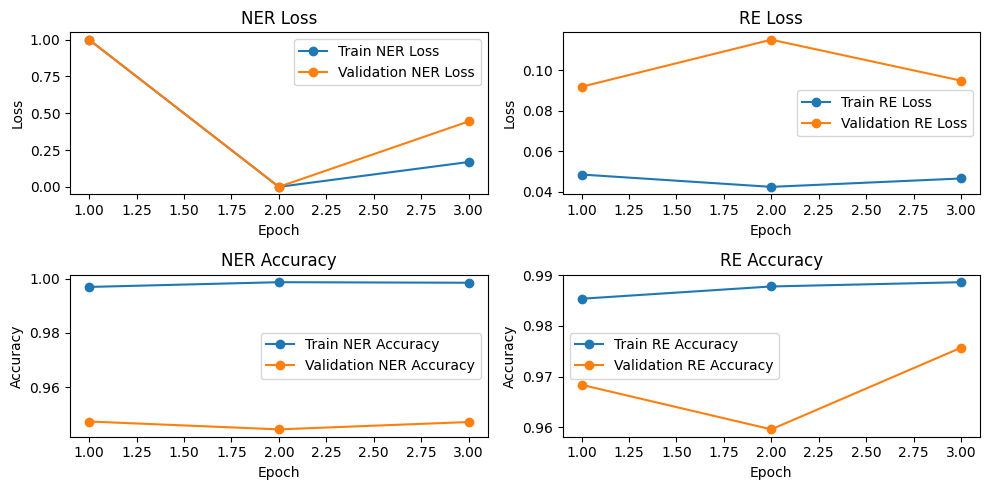

In [ ]:
import matplotlib.pyplot as plt

# Data from the training and validation process
epochs = [1, 2, 3]


# Plotting the loss curves
plt.figure(figsize=(10, 5))

# # Plot total loss
# plt.subplot(2, 2, 1)
# plt.plot(epochs, total_train_loss_list, label='Train Total Loss', marker='o')
# plt.plot(epochs, total_val_loss_list, label='Validation Total Loss', marker='o')
# plt.title('Total Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# Plot NER loss
plt.subplot(2, 2, 1)
plt.plot(epochs, ner_loss_list, label='Train NER Loss', marker='o')
plt.plot(epochs, val_ner_loss_list, label='Validation NER Loss', marker='o')
plt.title('NER Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot RE loss
plt.subplot(2, 2, 2)
plt.plot(epochs, re_loss_list, label='Train RE Loss', marker='o')
plt.plot(epochs, val_re_loss_list, label='Validation RE Loss', marker='o')
plt.title('RE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot NER accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, ner_accuracy_list, label='Train NER Accuracy', marker='o')
plt.plot(epochs, val_ner_accuracy_list, label='Validation NER Accuracy', marker='o')
plt.title('NER Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot RE accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, re_accuracy_list, label='Train RE Accuracy', marker='o')
plt.plot(epochs, val_re_accuracy_list, label='Validation RE Accuracy', marker='o')
plt.title('RE Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
!pip install seqeval

In [ ]:
# from sklearn.metrics import classification_report

# def evaluate_model_on_test(model, test_dataloader):
#     model.eval()  # Set the model to evaluation mode

#     all_ner_true_labels = []
#     all_ner_predicted_labels = []
#     all_re_true_labels = []
#     all_re_predicted_labels = []

#     with torch.no_grad():  # Disable gradient calculation
#         for batch in test_dataloader:
#             # Unpack the batch
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             entity_mask = batch['entity_mask'].to(device)
#             entity_type_ids = batch['entity_type_ids'].to(device)
#             ner_labels = batch['ner_labels'].to(device)
#             re_labels = batch['re_labels'].to(device)

#             # Forward pass
#             ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

#             # Decode NER predictions
#             predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

#             # Collect true NER labels and predictions for each batch (ignoring padding tokens)
#             for i in range(len(predicted_ner_labels)):
#                 true_labels = ner_labels[i].cpu().numpy()
#                 # pred_labels = predicted_ner_labels[i]

#                    # Ensure that predicted_ner_labels[i] is a tensor before calling .cpu()
#                 if isinstance(predicted_ner_labels[i], torch.Tensor):
#                     pred_labels = predicted_ner_labels[i].cpu().numpy()
#                 else:
#                     pred_labels = np.array(predicted_ner_labels[i])

#                 # Only consider non-padding tokens for NER accuracy
#                 non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)
#                 # Ensure we are slicing the true and predicted labels correctly
#                 true_labels = true_labels[non_padding_indices]
#                 pred_labels = pred_labels[:len(true_labels)]  # Ensure lengths match

#                 # Extend the true and predicted labels
#                 all_ner_true_labels.extend(true_labels)
#                 all_ner_predicted_labels.extend(pred_labels)

#             # Collect RE true labels and predictions
#             _, predicted_re_labels = torch.max(re_logits, 1)
#             all_re_true_labels.extend(re_labels.cpu().numpy())
#             all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

#     # Generate classification reports
#     ner_report = classification_report(all_ner_true_labels, all_ner_predicted_labels, zero_division=0)
#     re_report = classification_report(all_re_true_labels, all_re_predicted_labels, zero_division=0)

#     return ner_report, re_report

from seqeval.metrics import precision_score, recall_score, f1_score, classification_report as ner_classification_report
from sklearn.metrics import classification_report as re_classification_report

import numpy as np

import numpy as np

def evaluate_model_on_test(model, test_dataloader):
    model.eval()  # Set the model to evaluation mode
    all_ner_true_labels = []
    all_ner_predicted_labels = []
    all_re_true_labels = []
    all_re_predicted_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            # Unpack the batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            entity_mask = batch['entity_mask'].to(device)
            entity_type_ids = batch['entity_type_ids'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            re_labels = batch['re_labels'].to(device)

            # Forward pass
            ner_logits, re_logits, _ = model(input_ids, attention_mask, entity_type_ids, entity_mask)

            # Decode NER predictions using CRF layer
            predicted_ner_labels = model.decode_ner(ner_logits, attention_mask)

            # Collect NER true labels and predictions
            for i in range(len(predicted_ner_labels)):
                true_labels = ner_labels[i].cpu().numpy()
                pred_labels = np.array(predicted_ner_labels[i])  # Convert to NumPy array

                # Only consider non-padding tokens for NER accuracy
                valid_token_count = len(pred_labels)
                non_padding_indices = attention_mask[i].cpu().numpy().astype(bool)[:valid_token_count]

                all_ner_true_labels.append([neid2type[label] for label in true_labels[:valid_token_count] if label != 0])
                all_ner_predicted_labels.append([neid2type[label] for label in pred_labels if label != 0])

            # Collect RE true labels and predictions
            _, predicted_re_labels = torch.max(re_logits, 1)
            all_re_true_labels.extend(re_labels.cpu().numpy())
            all_re_predicted_labels.extend(predicted_re_labels.cpu().numpy())

    # Generate classification reports for NER and RE
    ner_report = ner_classification_report(all_ner_true_labels, all_ner_predicted_labels)
    re_report = re_classification_report([reid2type[label] for label in all_re_true_labels],
                                      [reid2type[label] for label in all_re_predicted_labels])

    return ner_report, re_report




In [ ]:
# Evaluate the trained model on the test data
ner_report, re_report = evaluate_model_on_test(model, test_dataloader)

# Print the classification reports for NER and RE tasks
print("NER Classification Report:")
print(ner_report)
print("\nRE Classification Report:")
print(re_report)


NER Classification Report:
              precision    recall  f1-score   support

        Area       0.71      0.72      0.71      7117
         Exp       0.99      1.00      1.00      1065
    Features       0.96      0.93      0.95       723
     HackOrg       0.81      0.86      0.84      3781
      OffAct       0.89      0.87      0.88      2382
         Org       0.85      0.86      0.86      6681
        Purp       0.90      0.87      0.88       725
     SamFile       0.91      0.95      0.93      1038
     SecTeam       0.90      0.82      0.86      1634
        Time       0.83      0.89      0.86      2342
        Tool       0.74      0.75      0.75      2851
         Way       0.77      0.81      0.79       790

   micro avg       0.81      0.83      0.82     31129
   macro avg       0.85      0.86      0.86     31129
weighted avg       0.82      0.83      0.82     31129


RE Classification Report:
                    precision    recall  f1-score   support

          analyses

In [ ]:
neid2type

{0: 'null',
 1: 'O',
 2: 'B-Area',
 3: 'I-Area',
 4: 'B-Exp',
 5: 'I-Exp',
 6: 'B-Features',
 7: 'I-Features',
 8: 'B-HackOrg',
 9: 'I-HackOrg',
 10: 'B-OffAct',
 11: 'I-OffAct',
 12: 'B-Org',
 13: 'I-Org',
 14: 'B-Purp',
 15: 'I-Purp',
 16: 'B-SamFile',
 17: 'I-SamFile',
 18: 'B-SecTeam',
 19: 'I-SecTeam',
 20: 'B-Time',
 21: 'I-Time',
 22: 'B-Tool',
 23: 'I-Tool',
 24: 'B-Way',
 25: 'I-Way'}

In [ ]:
# Dummy batch size and sequence length
batch_size = 2
seq_len = 5

# Number of NER and RE labels
num_ner_labels = 26
num_re_labels = 12

# Ensure input_ids and token_type_ids are of type LongTensor
dummy_input_ids = torch.randint(0, 30522, (batch_size, seq_len), dtype=torch.long).to(device)
dummy_attention_mask = torch.ones(batch_size, seq_len, dtype=torch.long).to(device)  # Attention mask can also be long
dummy_token_type_ids = torch.zeros(batch_size, seq_len, dtype=torch.long).to(device)  # No segment distinction

# Dummy labels for NER and RE (LongTensor not needed for these, but you can keep them as Long if desired)
dummy_ner_labels = torch.randint(0, num_ner_labels, (batch_size, seq_len)).to(device)
dummy_re_labels = torch.randint(0, num_re_labels, (batch_size,)).to(device)

# Pass the dummy data through the model without NER labels
ner_logits, re_logits, ner_loss = model(dummy_input_ids, dummy_attention_mask, dummy_token_type_ids)

# Check the output shapes
print(f"NER logits shape: {ner_logits.shape}")  # (batch_size, seq_len, num_ner_labels)
print(f"RE logits shape: {re_logits.shape}")    # (batch_size, num_re_labels)
print(f"NER loss (without labels): {ner_loss}")  # Should be None since no labels were provided

# Now, pass the dummy data through the model with NER labels (for computing NER loss)
ner_logits, re_logits, ner_loss = model(dummy_input_ids, dummy_attention_mask, dummy_token_type_ids, ner_labels=dummy_ner_labels)

# Check the output shapes again
print(f"NER logits shape: {ner_logits.shape}")  # (batch_size, seq_len, num_ner_labels)
print(f"RE logits shape: {re_logits.shape}")    # (batch_size, num_re_labels)
print(f"NER loss (with labels): {ner_loss}")    # Should be a tensor with the NER loss value


TypeError: JointExtractionModel.forward() missing 1 required positional argument: 'entity_mask'

In [ ]:
2 + 2